# 🚔 San Francisco Crime Category Classification
## Complete Machine Learning Pipeline —  Project
---

**Dataset**: San Francisco Crime Classification  
**Goal**: Predict the `Category` of a crime from features like location, time, and district  
**Models**: Neural Network · SVM · Logistic Regression · Decision Tree  
**Extra**: PCA Dimensionality Reduction + Hyperparameter Tuning + Full Comparison

---

###  Notebook Structure

| Section | Description |
|---------|-------------|
| 1 | Data Loading & Exploration |
| 2 | Data Preprocessing & Feature Engineering |
| 3 | PCA — Dimensionality Reduction |
| 4 | Model Training (Original + PCA data) |
| 5 | Evaluation Function + Results |
| 6 | Comparison Table |
| 7 | Visualizations |
| 8 | Hyperparameter Tuning |
| 9 | Final Summary & Best Model |


---
##  Section 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn tools ──
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ── Models ──
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# ── Visualization style ──
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(' All libraries imported successfully!')


 All libraries imported successfully!


---
##  Section 2 — Data Loading & Exploration



In [3]:
# ── Load Data ──
df = pd.read_csv(r"C:\Users\img\Desktop\python project\ML project\ANN Moldel\crime data.csv.csv")


print(' Data loaded successfully!')
print(f'   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Columns: {df.columns.tolist()}')


 Data loaded successfully!
   Shape: 878,049 rows × 9 columns
   Columns: ['Dates', 'Category', 'Descript', 'DayOfWeek', 'PdDistrict', 'Resolution', 'Address', 'X', 'Y']


In [3]:
# ── First 5 rows ──
print('=== First 5 Rows ===')
df.head()


=== First 5 Rows ===


,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414
3,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,NORTHERN,NONE,1500 Block of LOMBARD ST,-122.426995,37.800873
4,2015-05-13 23:30:00,LARCENY/THEFT,GRAND THEFT FROM LOCKED AUTO,Wednesday,PARK,NONE,100 Block of BRODERICK ST,-122.438738,37.771541


In [4]:
# ── Data types & missing values ──
print('=== Data Types & Non-Null Counts ===')
df.info()

print('\n=== Missing Values ===')
missing = df.isnull().sum()
if missing.sum() == 0:
    print(' No missing values found!')
else:
    print(missing[missing > 0])


=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878049 entries, 0 to 878048
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Dates       878049 non-null  object 
 1   Category    878049 non-null  object 
 2   Descript    878049 non-null  object 
 3   DayOfWeek   878049 non-null  object 
 4   PdDistrict  878049 non-null  object 
 5   Resolution  878049 non-null  object 
 6   Address     878049 non-null  object 
 7   X           878049 non-null  float64
 8   Y           878049 non-null  float64
dtypes: float64(2), object(7)
memory usage: 60.3+ MB

=== Missing Values ===
 No missing values found!


In [5]:
# ── Statistical summary ──
print('=== Statistical Summary (Numerical Columns) ===')
df.describe()


=== Statistical Summary (Numerical Columns) ===


,X,Y
count,878049.000000,878049.000000
mean,-122.422616,37.771020
std,0.030354,0.456893
min,-122.513642,37.707879
25%,-122.432952,37.752427
50%,-122.416420,37.775421
75%,-122.406959,37.784369
max,-120.500000,90.000000


In [6]:
# ── Target variable distribution ──
print(f'=== Target Variable: Category ===')
print(f'Total unique crime categories: {df["Category"].nunique()}')
print('\nTop 15 most frequent categories:')
print(df['Category'].value_counts().head(15))


=== Target Variable: Category ===
Total unique crime categories: 39

Top 15 most frequent categories:
Category
LARCENY/THEFT             174900
OTHER OFFENSES            126182
NON-CRIMINAL               92304
ASSAULT                    76876
DRUG/NARCOTIC              53971
VEHICLE THEFT              53781
VANDALISM                  44725
WARRANTS                   42214
BURGLARY                   36755
SUSPICIOUS OCC             31414
MISSING PERSON             25989
ROBBERY                    23000
FRAUD                      16679
FORGERY/COUNTERFEITING     10609
SECONDARY CODES             9985
Name: count, dtype: int64


---
##  Section 3 — Exploratory Data Analysis (EDA)

Five visualizations to understand the data before building any model.


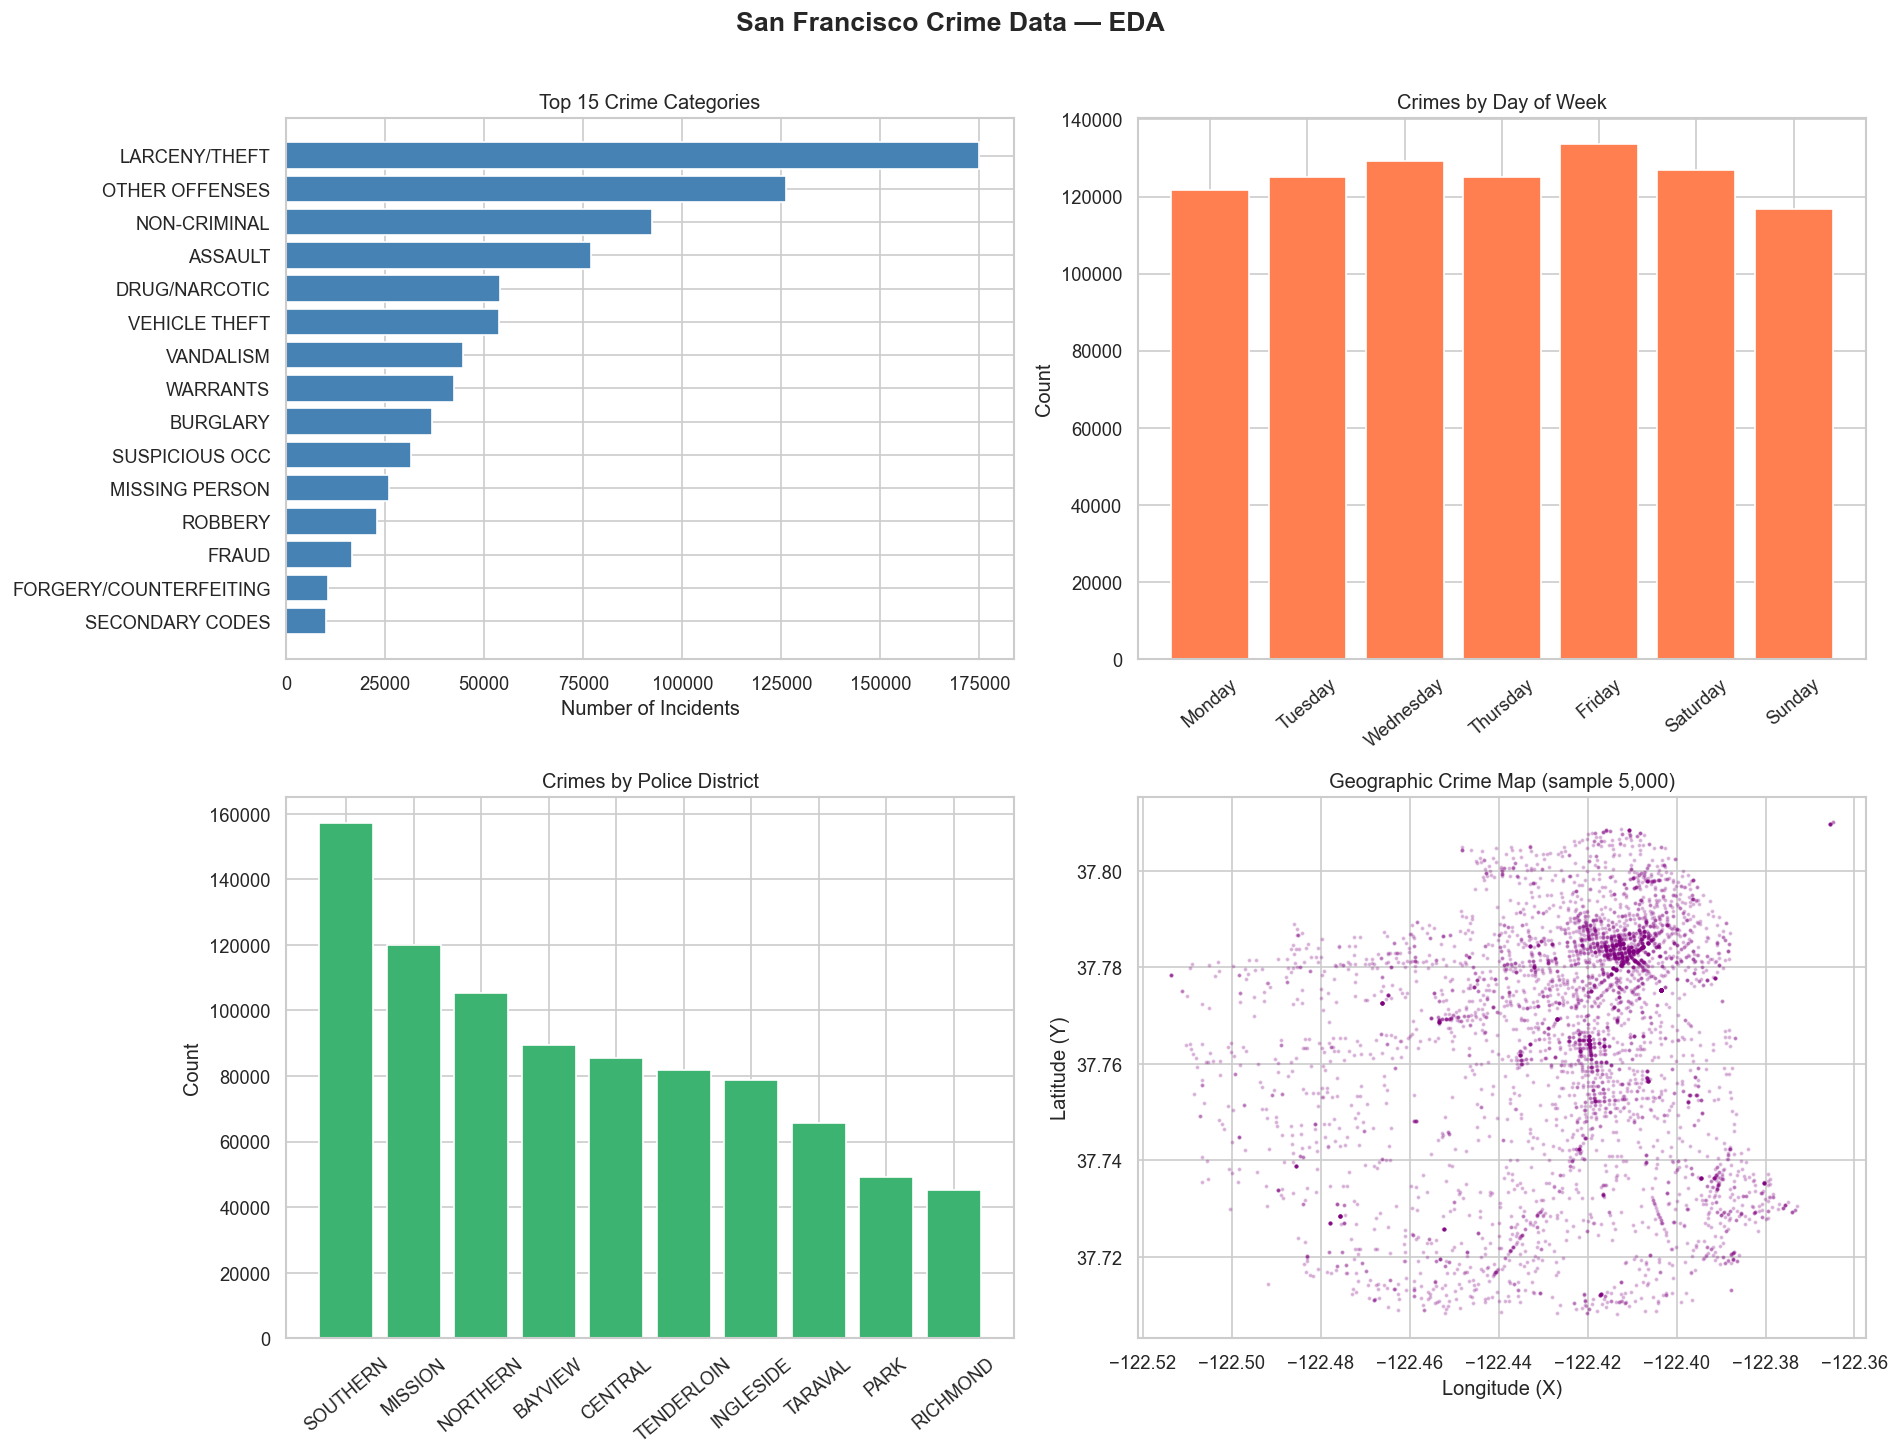

 EDA visualizations saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('San Francisco Crime Data — EDA', fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1: Top 15 Crime Categories ──
top15 = df['Category'].value_counts().head(15)
axes[0, 0].barh(top15.index[::-1], top15.values[::-1], color='steelblue')
axes[0, 0].set_title('Top 15 Crime Categories')
axes[0, 0].set_xlabel('Number of Incidents')

# ── Plot 2: Crimes by Day of Week ──
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['DayOfWeek'].value_counts().reindex(day_order)
axes[0, 1].bar(day_counts.index, day_counts.values, color='coral')
axes[0, 1].set_title('Crimes by Day of Week')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=40)

# ── Plot 3: Crimes by Police District ──
district_counts = df['PdDistrict'].value_counts()
axes[1, 0].bar(district_counts.index, district_counts.values, color='mediumseagreen')
axes[1, 0].set_title('Crimes by Police District')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=40)

# ── Plot 4: Geographic Map of Crimes ──
# Filter outlier coordinates (Y > 40 means bad GPS data) and take sample not full 
sample = df[df['Y'] < 40].sample(5000, random_state=42)
axes[1, 1].scatter(sample['X'], sample['Y'], alpha=0.2, s=2, color='purple')
axes[1, 1].set_title('Geographic Crime Map (sample 5,000)')
axes[1, 1].set_xlabel('Longitude (X)')
axes[1, 1].set_ylabel('Latitude (Y)')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(' EDA visualizations saved!')


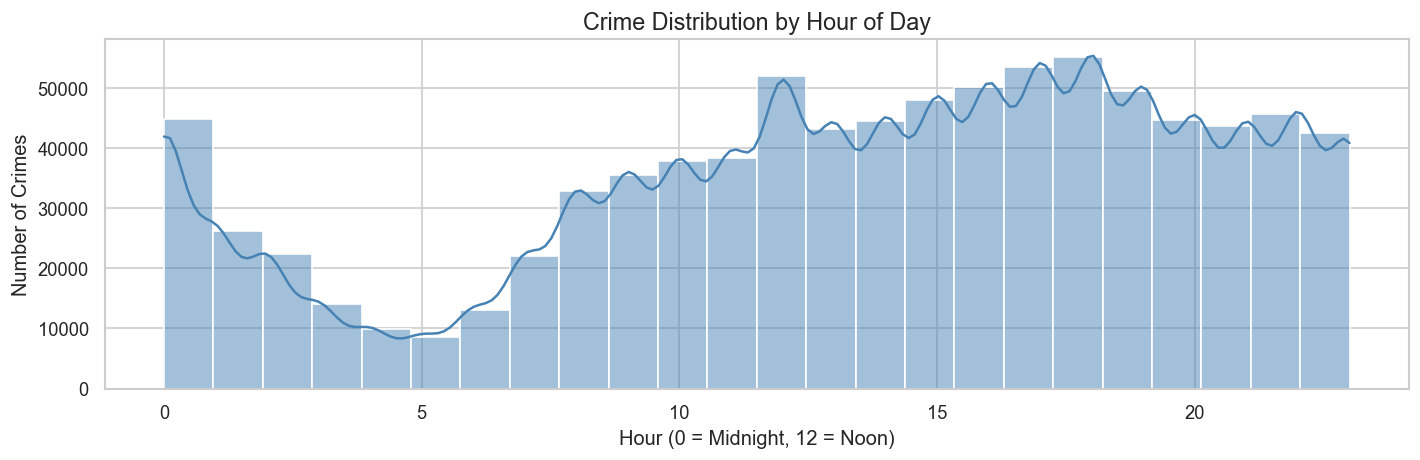

 Insight: Crimes typically spike in the afternoon/evening (12:00–18:00)


In [8]:
# ── Plot 5: Crime Hour Distribution ──
df_temp = df.copy()
df_temp['Dates'] = pd.to_datetime(df_temp['Dates'])
df_temp['Hour'] = df_temp['Dates'].dt.hour

plt.figure(figsize=(12, 4))
sns.histplot(df_temp['Hour'], bins=24, kde=True, color='steelblue')
plt.title('Crime Distribution by Hour of Day', fontsize=14)
plt.xlabel('Hour (0 = Midnight, 12 = Noon)')
plt.ylabel('Number of Crimes')
plt.tight_layout()
plt.savefig('eda_crime_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Insight: Crimes typically spike in the afternoon/evening (12:00–18:00)')


---
##  Section 4 — Data Preprocessing & Feature Engineering

### Steps:
1. Parse datetime → extract useful features (Hour, DayOfMonth, Month, Year)
2. Drop irrelevant/leaky columns (Descript, Resolution, Address)
3. Label-encode categorical features (DayOfWeek, PdDistrict, Category)
4. Filter GPS outliers
5. Scale features with StandardScaler
6. Train/Test split


In [9]:
# ── Step 1: Parse Dates & Extract Features ──
df['Dates']      = pd.to_datetime(df['Dates'])
df['Hour']       = df['Dates'].dt.hour
df['DayOfMonth'] = df['Dates'].dt.day
df['Month']      = df['Dates'].dt.month
df['Year']       = df['Dates'].dt.year

print(' Date features extracted: Hour, DayOfMonth, Month, Year')

# ── Step 2: Drop leaky/unusable columns ── for handling laekage
cols_to_drop = ['Dates', 'Descript', 'Resolution', 'Address']
# Only drop columns that exist
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True## edit on prime data)

print(f' Dropped columns: {cols_to_drop}')
print(f'   Remaining columns: {df.columns.tolist()}')


 Date features extracted: Hour, DayOfMonth, Month, Year
 Dropped columns: ['Dates', 'Descript', 'Resolution', 'Address']
   Remaining columns: ['Category', 'DayOfWeek', 'PdDistrict', 'X', 'Y', 'Hour', 'DayOfMonth', 'Month', 'Year']


In [11]:
# ── Step 3: Filter GPS outliers ──
# Y (Latitude) > 40 means bad/missing GPS data — San Francisco is ~37.7°N 
before = len(df)
df = df[df['Y'] < 40].reset_index(drop=True)
print(f' GPS outlier rows removed: {before - len(df)}')
print(f'   Dataset size after filtering: {len(df):,} rows')


 GPS outlier rows removed: 0
   Dataset size after filtering: 877,982 rows


In [12]:
# ── Step 4: Label Encoding ──
le_day      = LabelEncoder()
le_district = LabelEncoder()
le_target   = LabelEncoder()

df['DayOfWeek_enc']  = le_day.fit_transform(df['DayOfWeek'])
df['PdDistrict_enc'] = le_district.fit_transform(df['PdDistrict'])
df['Category_enc']   = le_target.fit_transform(df['Category'])

num_classes = len(le_target.classes_)
print(f' Label encoding done.')
print(f'   Number of crime categories (classes): {num_classes}')
print(f'   Sample: Monday → {le_day.transform(["Monday"])[0]}') ## sample of encoding


 Label encoding done.
   Number of crime categories (classes): 39
   Sample: Monday → 1


In [13]:
# ── Step 5: Define Features (X) and Target (y) ──
FEATURES = ['X', 'Y', 'Hour', 'DayOfWeek_enc', 'PdDistrict_enc',
            'DayOfMonth', 'Month', 'Year']
## x,y is numpy array (sklearn use it fasr)
X = df[FEATURES].values
y = df['Category_enc'].values

print(f' Features defined.')
print(f'   Feature columns: {FEATURES}')
print(f'   X shape: {X.shape}')
print(f'   y shape: {y.shape}')


 Features defined.
   Feature columns: ['X', 'Y', 'Hour', 'DayOfWeek_enc', 'PdDistrict_enc', 'DayOfMonth', 'Month', 'Year']
   X shape: (877982, 8)
   y shape: (877982,)


In [14]:
# ── Step 6: Train / Test Split ──
# 80% training, 20% testing
# stratify=y → preserve class proportions in both sets(for not inplace and not bais)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(' Train/Test split done.')
print(f'   Training size : {X_train.shape[0]:,} rows')
print(f'   Testing size  : {X_test.shape[0]:,} rows')


 Train/Test split done.
   Training size : 702,385 rows
   Testing size  : 175,597 rows


In [15]:
# ── Step 7: Feature Scaling ──
#  IMPORTANT: fit ONLY on train data — never on test data (data leakage!)
# StandardScaler → mean=0, std=1 for each feature
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(' Feature scaling done.')
print(f'   Train mean (should be ≈0): {X_train_scaled.mean():.6f}')
print(f'   Train std  (should be ≈1): {X_train_scaled.std():.6f}')


 Feature scaling done.
   Train mean (should be ≈0): -0.000000
   Train std  (should be ≈1): 1.000000


---
## 🔬 Section 5 — PCA (Dimensionality Reduction)

**What is PCA?**  
PCA (Principal Component Analysis) transforms the original features into a smaller set of new features (principal components) that capture most of the variance in the data.

**Why use PCA?**
- Reduces training time
- Removes redundant/correlated features
- Can improve some models by reducing noise

We apply PCA with `n_components=0.95` → keeps enough components to explain **95%** of variance.


In [16]:
# ── Apply PCA ──
# n_components=0.95 → automatically picks enough components for 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)  # fit on train only! for escape data leakage
X_test_pca  = pca.transform(X_test_scaled)        # apply same transform to test

n_components = pca.n_components_
total_variance = pca.explained_variance_ratio_.sum() * 100

print(' PCA applied.')
print(f'   Original features  : {X_train_scaled.shape[1]}')
print(f'   After PCA features : {n_components}')
print(f'   Variance retained  : {total_variance:.2f}%')
print('\nExplained variance per component:')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {var*100:.2f}%')


 PCA applied.
   Original features  : 8
   After PCA features : 8
   Variance retained  : 100.00%

Explained variance per component:
  PC1: 17.00%
  PC2: 14.44%
  PC3: 13.20%
  PC4: 12.65%
  PC5: 12.51%
  PC6: 12.28%
  PC7: 11.83%
  PC8: 6.09%


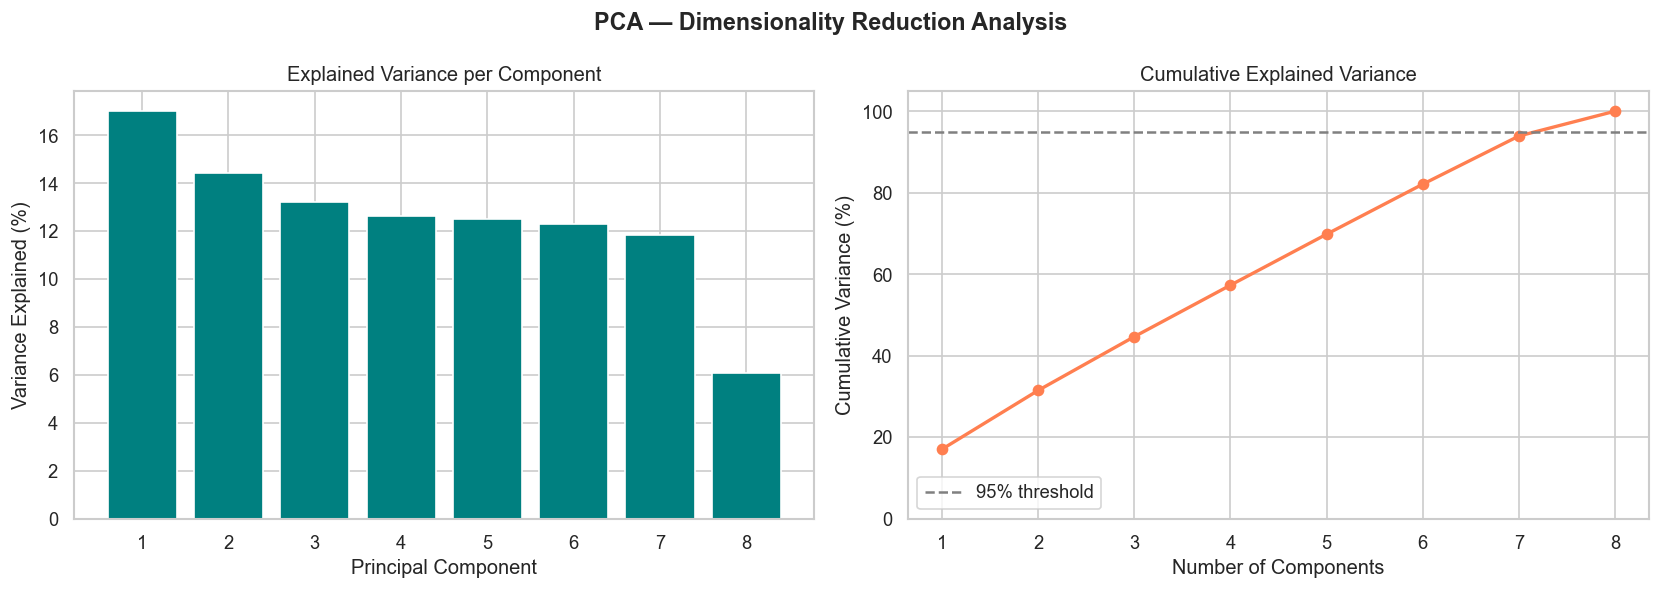

 PCA analysis plot saved!


In [17]:
# ── PCA Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA — Dimensionality Reduction Analysis', fontsize=14, fontweight='bold')

# Plot 1: Variance per component (bar)
axes[0].bar(range(1, n_components + 1),
            pca.explained_variance_ratio_ * 100,
            color='teal', edgecolor='white')
axes[0].set_title('Explained Variance per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')

# Plot 2: Cumulative variance
cumulative = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(range(1, n_components + 1), cumulative,
             marker='o', color='coral', linewidth=2)
axes[1].axhline(y=95, color='gray', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(' PCA analysis plot saved!')


---
##  Section 6 — Evaluation Function

A **reusable function** that computes all metrics for any trained model.

It accepts both original and PCA-transformed data.

Accuracy=Total Predictions/Correct Predictions

Precision=TP/(TP+FP)

Recall=TP/(TP+FN)

F1=2((Precision×Recall)/(Precision+Recall))

overfit=train_acc-(val/test_acc)

In [18]:
# ── REUSABLE EVALUATION FUNCTION ──
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name='Model', show_confusion=True):
    """
    Evaluate a trained model and return all key metrics.
    
    Parameters
    ----------
    model      : trained sklearn model
    X_tr, y_tr : training features and labels
    X_te, y_te : testing features and labels
    model_name : display name for the model
    show_confusion : whether to plot the confusion matrix
    
    Returns
    -------
    dict with all metrics
    """
    # ── Predictions ──
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)
    
    # ── Metrics ──zero_div for error, av= weight for weighten result for size of class
    train_acc = accuracy_score(y_tr, y_pred_train) * 100
    test_acc  = accuracy_score(y_te, y_pred_test)  * 100
    precision = precision_score(y_te, y_pred_test, average='weighted', zero_division=0) * 100 
    recall    = recall_score(y_te, y_pred_test,    average='weighted', zero_division=0) * 100
    f1        = f1_score(y_te, y_pred_test,        average='weighted', zero_division=0) * 100
    overfit   = train_acc - test_acc
    
    # ── Print results ──
    print(f'\n{"=" * 55}')
    print(f'   {model_name}')
    print(f'{"=" * 55}')
    print(f'  Train Accuracy : {train_acc:.2f}%')
    print(f'  Test  Accuracy : {test_acc:.2f}%')
    print(f'  Overfitting    : {overfit:.2f}% ({" HIGH" if overfit > 10 else " OK"})')
    print(f'  Precision      : {precision:.2f}%')
    print(f'  Recall         : {recall:.2f}%')
    print(f'  F1-Score       : {f1:.2f}%')
    
    # ── Confusion Matrix ──
    if show_confusion:
        # Only show top-N classes to keep it readable
        top_n = min(10, len(np.unique(y_te)))
        top_classes = pd.Series(y_te).value_counts().head(top_n).index.tolist()
        mask = pd.Series(y_te).isin(top_classes).values
        
        cm = confusion_matrix(y_te[mask], y_pred_test[mask], labels=top_classes)
        class_names = le_target.inverse_transform(top_classes)
        
        fig, ax = plt.subplots(figsize=(10, 7))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
        ax.set_title(f'Confusion Matrix — {model_name} (Top {top_n} Classes)',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'cm_{model_name.replace(" ", "_").lower()}.png',
                    dpi=120, bbox_inches='tight')
        plt.show()
    
    return {
        'model': model_name,
        'train_acc': round(train_acc, 2),
        'test_acc':  round(test_acc,  2),
        'precision': round(precision, 2),
        'recall':    round(recall,    2),
        'f1':        round(f1,        2),
        'overfit':   round(overfit,   2)
    }

# Storage for all results
results = []

print(' Evaluation function defined and ready!')


 Evaluation function defined and ready!


---
##  Section 7 — Model Training & Evaluation

Each model is trained **twice**:
1. On the **original scaled** data
2. On the **PCA-transformed** data

This lets us directly compare whether PCA helps or hurts each model.


### 7.1 — Decision Tree Classifier

 Training Decision Tree on original data...
 Done!

   Decision Tree (Original)
  Train Accuracy : 26.20%
  Test  Accuracy : 25.74%
  Overfitting    : 0.45% ( OK)
  Precision      : 19.86%
  Recall         : 25.74%
  F1-Score       : 19.19%


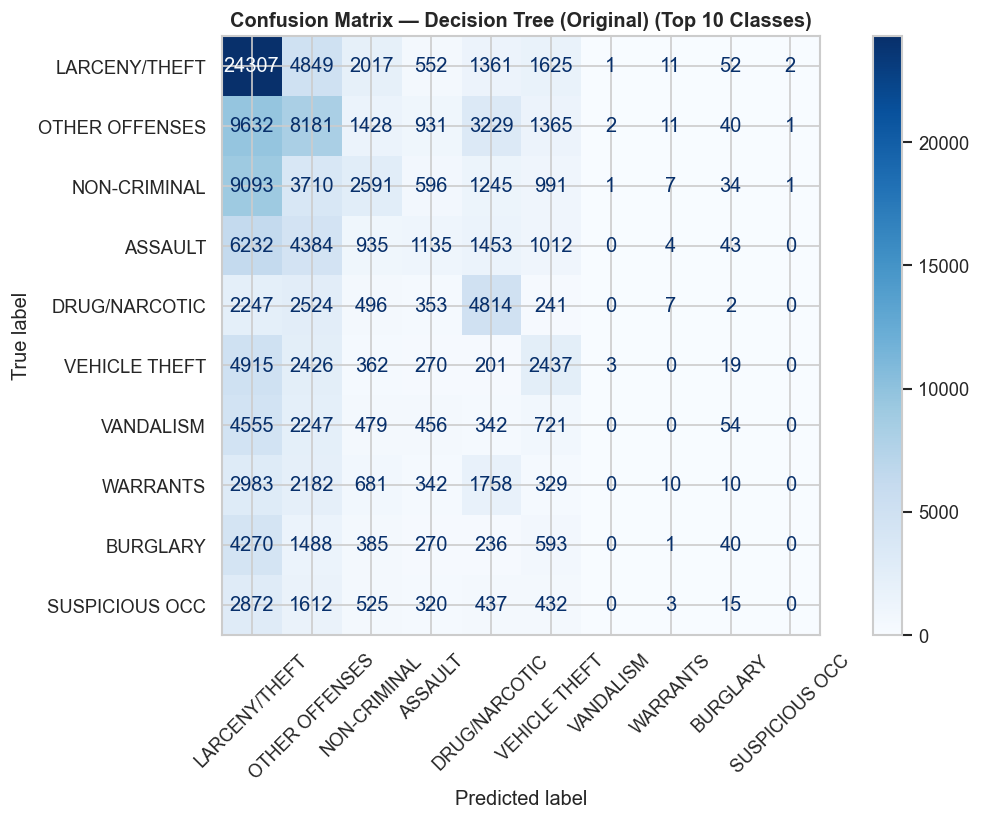

In [19]:
# ── Decision Tree — Original Data ──
print(' Training Decision Tree on original data...')
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train_scaled, y_train)
print(' Done!')

res = evaluate_model(dt_model, X_train_scaled, y_train,
                     X_test_scaled, y_test,
                     model_name='Decision Tree (Original)')
results.append(res)


 Training Decision Tree on PCA data...
 Done!

   Decision Tree (PCA)
  Train Accuracy : 25.02%
  Test  Accuracy : 24.31%
  Overfitting    : 0.70% ( OK)
  Precision      : 18.36%
  Recall         : 24.31%
  F1-Score       : 16.72%


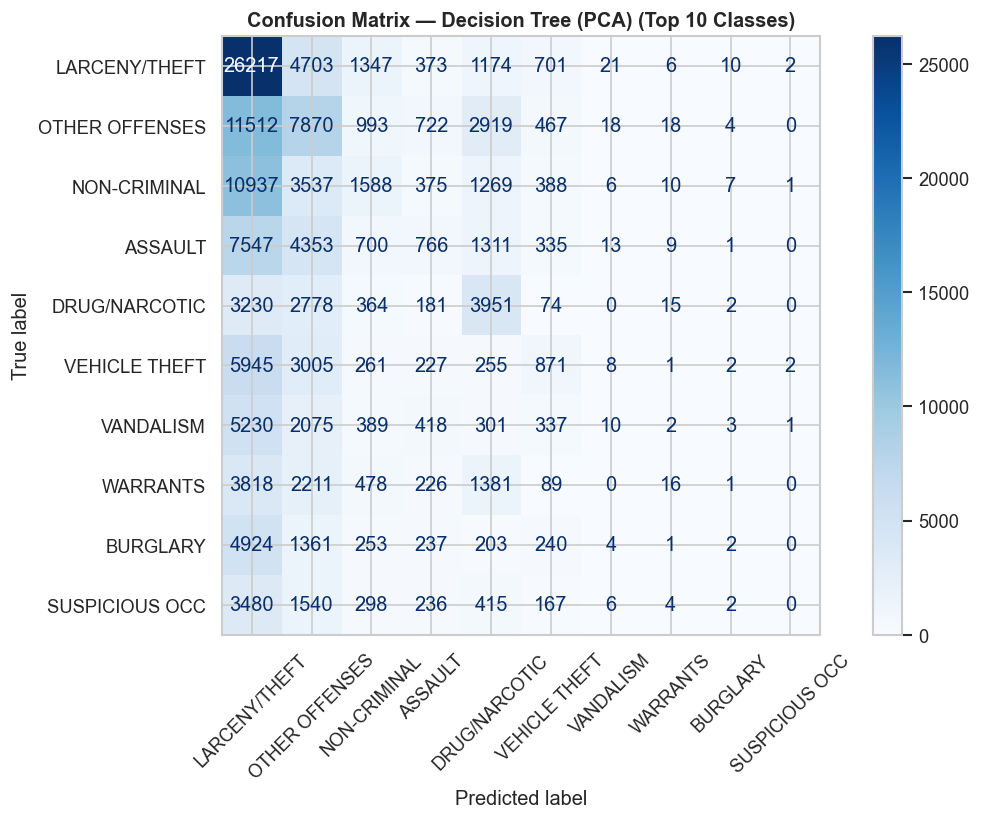

In [20]:
# ── Decision Tree — PCA Data ──
print(' Training Decision Tree on PCA data...')
dt_pca_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_pca_model.fit(X_train_pca, y_train)
print(' Done!')

res = evaluate_model(dt_pca_model, X_train_pca, y_train,
                     X_test_pca, y_test,
                     model_name='Decision Tree (PCA)')
results.append(res)


### 7.2 — Logistic Regression

 Training Logistic Regression on original data...
 Done!

   Logistic Regression (Original)
  Train Accuracy : 21.51%
  Test  Accuracy : 21.50%
  Overfitting    : 0.01% ( OK)
  Precision      : 10.98%
  Recall         : 21.50%
  F1-Score       : 11.37%


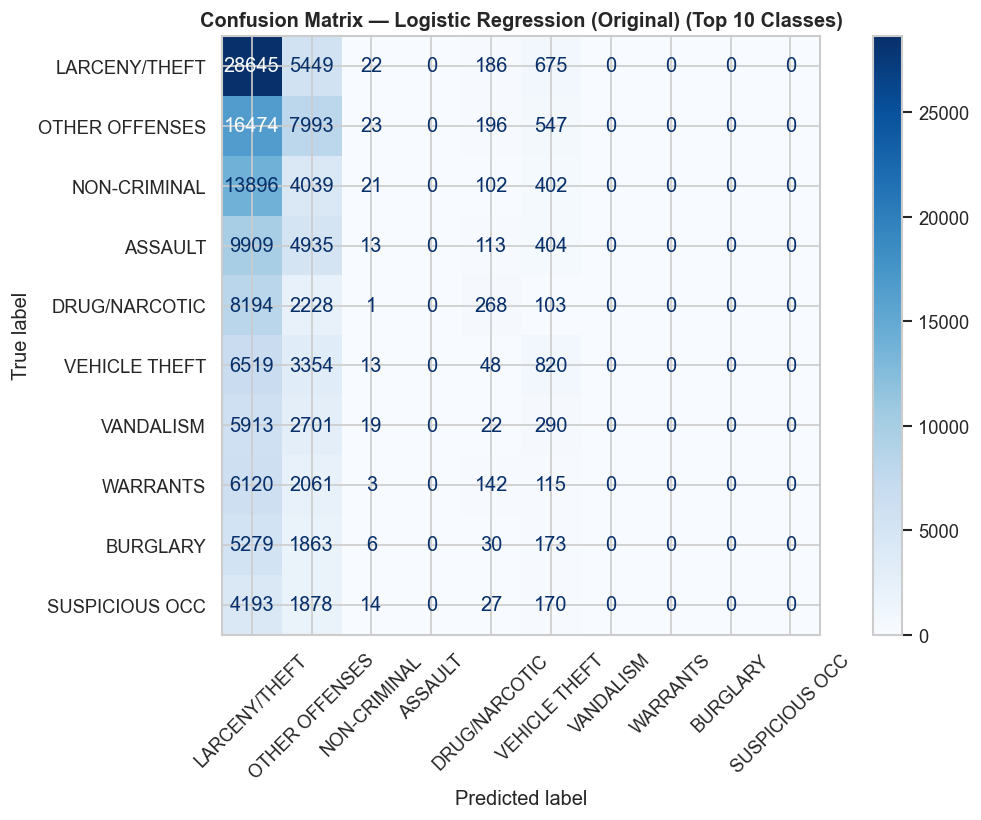

In [21]:
# ── Logistic Regression — Original Data ──
# max_iter=500 for convergence on this dataset
# C=1.0 → default regularization strength
print(' Training Logistic Regression on original data...')
lr_model = LogisticRegression(C=1.0, max_iter=500, random_state=42, n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)
print(' Done!')

res = evaluate_model(lr_model, X_train_scaled, y_train,
                     X_test_scaled, y_test,
                     model_name='Logistic Regression (Original)')
results.append(res)


 Training Logistic Regression on PCA data...
 Done!

   Logistic Regression (PCA)
  Train Accuracy : 21.51%
  Test  Accuracy : 21.50%
  Overfitting    : 0.01% ( OK)
  Precision      : 10.98%
  Recall         : 21.50%
  F1-Score       : 11.37%


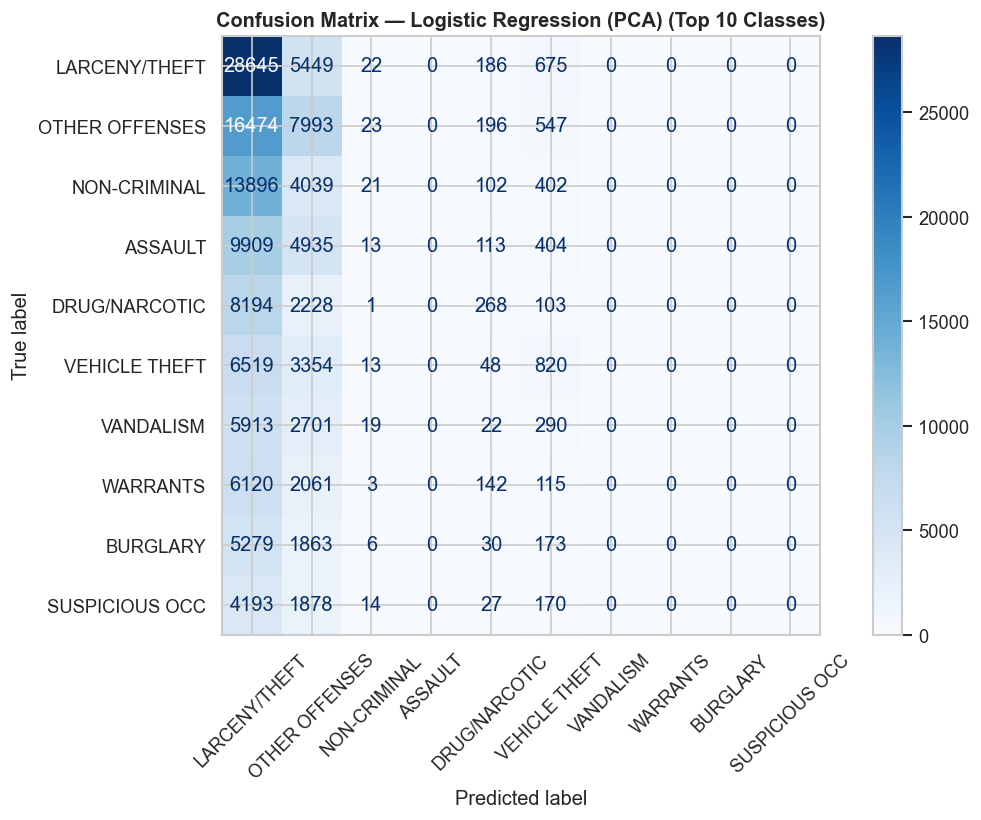

In [22]:
# ── Logistic Regression — PCA Data ──
print(' Training Logistic Regression on PCA data...')
lr_pca_model = LogisticRegression(C=1.0, max_iter=500, random_state=42, n_jobs=-1)
lr_pca_model.fit(X_train_pca, y_train)
print(' Done!')

res = evaluate_model(lr_pca_model, X_train_pca, y_train,
                     X_test_pca, y_test,
                     model_name='Logistic Regression (PCA)')
results.append(res)


### 7.3 — Support Vector Machine (SVM)

> **Note**: We use `LinearSVC` (linear kernel) instead of `SVC` because standard SVM scales as O(n²) and is too slow for 50K rows. `LinearSVC` achieves similar accuracy in a fraction of the time.


 Training LinearSVC on original data...
 Done!

   SVM LinearSVC (Original)
  Train Accuracy : 21.31%
  Test  Accuracy : 21.30%
  Overfitting    : 0.01% ( OK)
  Precision      : 9.43%
  Recall         : 21.30%
  F1-Score       : 10.44%


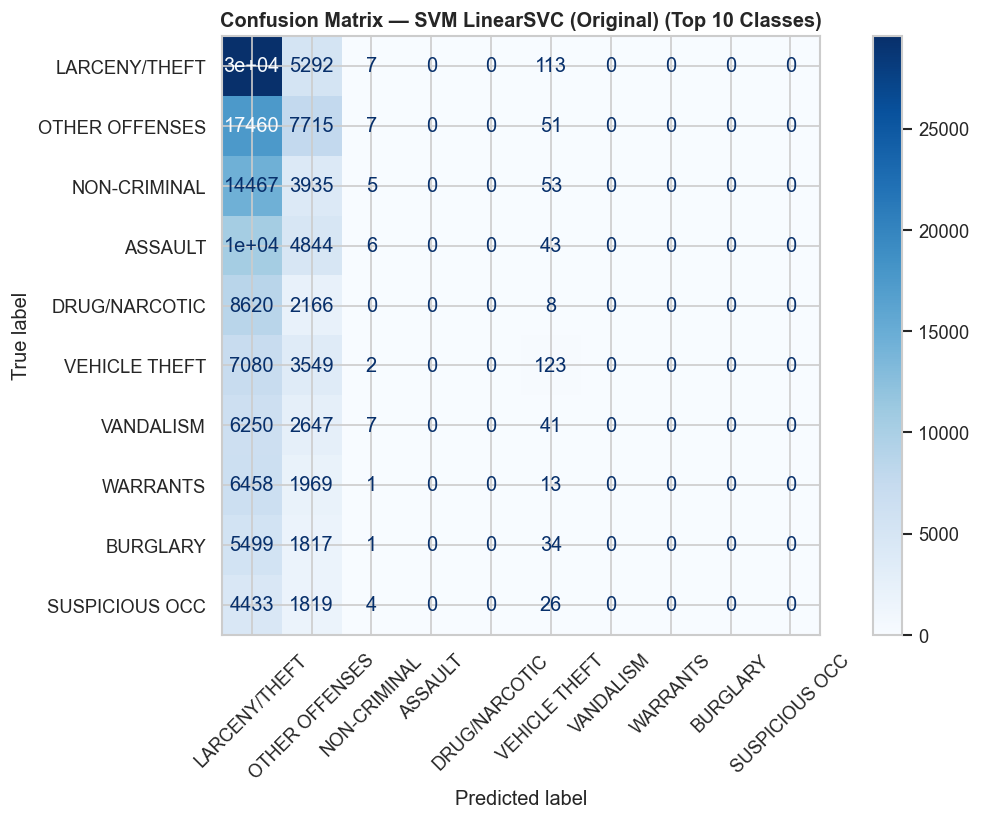

In [23]:
# ── SVM (LinearSVC) — Original Data ──
# LinearSVC is much faster than SVC for large datasets
# C=1.0 → regularization (lower C = more regularization)
print(' Training LinearSVC on original data...')
svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model.fit(X_train_scaled, y_train)
print(' Done!')

res = evaluate_model(svm_model, X_train_scaled, y_train,
                     X_test_scaled, y_test,
                     model_name='SVM LinearSVC (Original)')
results.append(res)


 Training LinearSVC on PCA data...
 Done!

   SVM LinearSVC (PCA)
  Train Accuracy : 21.31%
  Test  Accuracy : 21.30%
  Overfitting    : 0.01% ( OK)
  Precision      : 9.43%
  Recall         : 21.30%
  F1-Score       : 10.44%


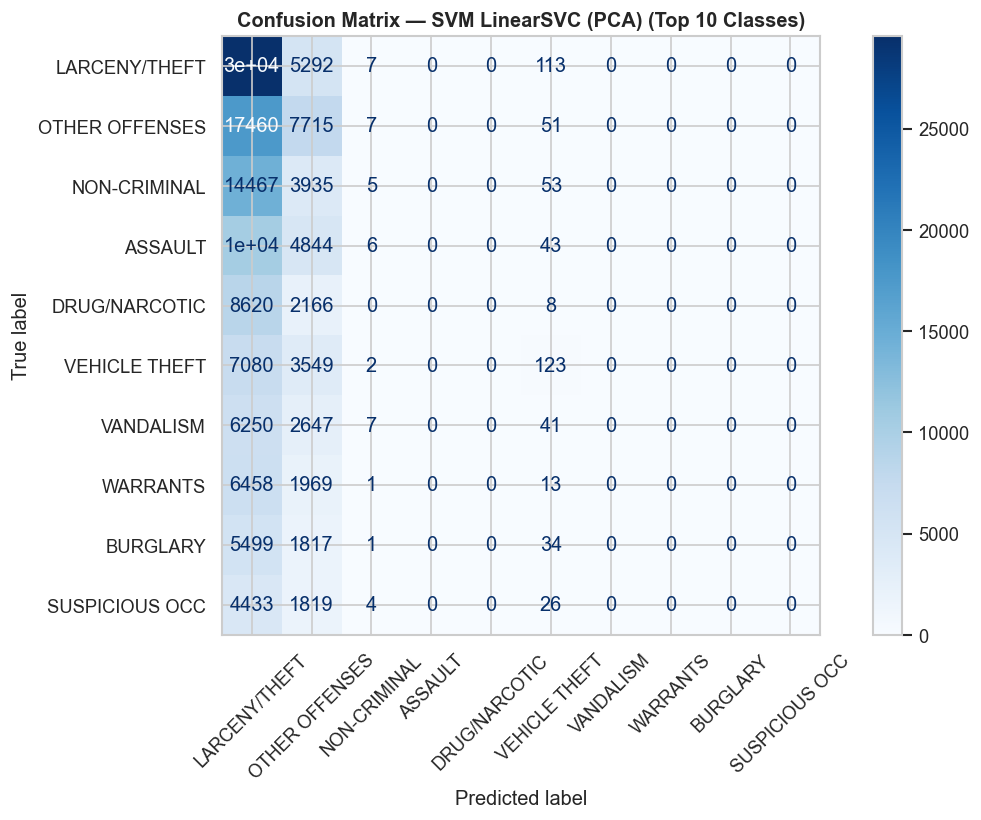

In [24]:
# ── SVM (LinearSVC) — PCA Data ──
print(' Training LinearSVC on PCA data...')
svm_pca_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_pca_model.fit(X_train_pca, y_train)
print(' Done!')

res = evaluate_model(svm_pca_model, X_train_pca, y_train,
                     X_test_pca, y_test,
                     model_name='SVM LinearSVC (PCA)')
results.append(res)


### 7.4 — Neural Network (MLP)

**Architecture**: 3 hidden layers -> 256 -> 128 -> 64 neurons  
**Activation**: ReLU  
**Optimizer**: Adam  
**Regularization**: L2 (alpha=0.001) + Early Stopping


 Training Neural Network on original data ...
 Done!

   Neural Network (Original)
  Train Accuracy : 27.09%
  Test  Accuracy : 26.78%
  Overfitting    : 0.31% ( OK)
  Precision      : 21.18%
  Recall         : 26.78%
  F1-Score       : 20.02%


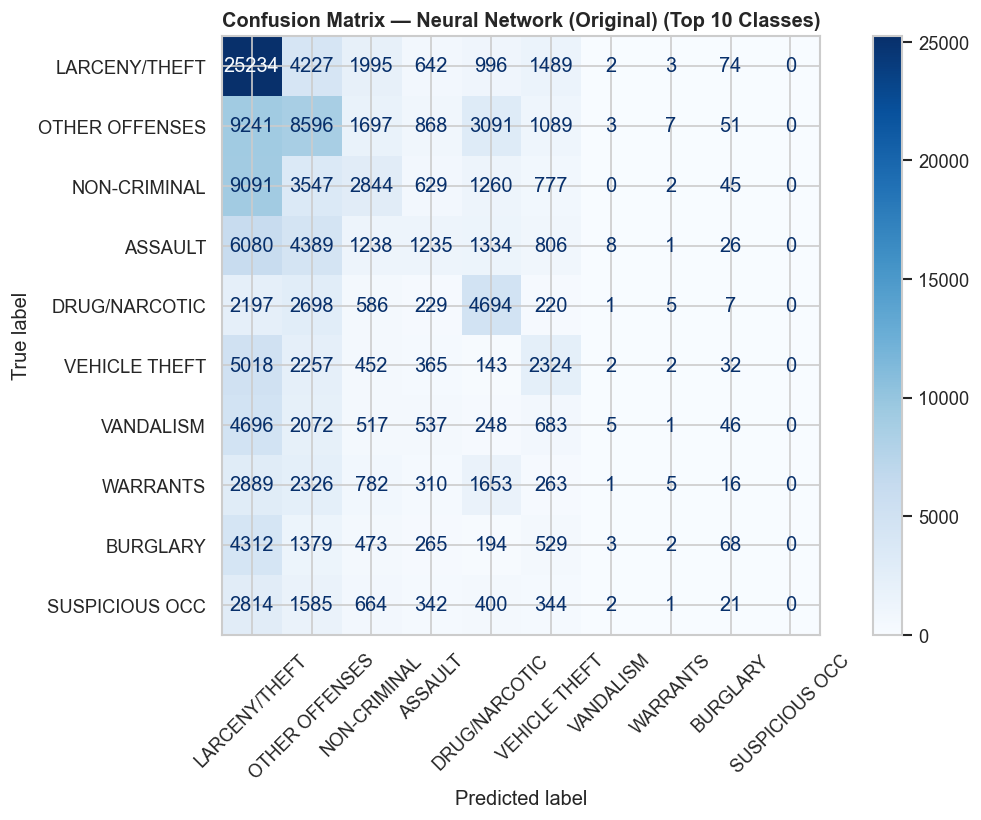

In [25]:
# ── Neural Network — Original Data ──
# MLPClassifier = Multi-Layer Perceptron (feedforward Neural Network)
print(' Training Neural Network on original data ...')
nn_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),  # 3 hidden layers
    activation='relu',                  # ReLU activation function Fw(0,max)
    solver='adam',                      # Adam optimizer for weights
    alpha=0.001,                        # L2 regularization for overfitting
    learning_rate_init=0.001,           # Initial learning rate(How to changee weights)
    max_iter=100,                       # Maximum epochs(Max iter in data)
    batch_size=512,                     # Mini-batch size for one itr
    early_stopping=True,                # Stop if val loss doesn't improve
    validation_fraction=0.1,            #  take 10% of train for validation
    n_iter_no_change=10,                # if  it has 10 iter without improve stop
    random_state=42
)
nn_model.fit(X_train_scaled, y_train)
print(' Done!')

res = evaluate_model(nn_model, X_train_scaled, y_train,
                     X_test_scaled, y_test,
                     model_name='Neural Network (Original)')
results.append(res)


 Training Neural Network on PCA data...
 Done!

   Neural Network (PCA)
  Train Accuracy : 27.34%
  Test  Accuracy : 26.82%
  Overfitting    : 0.51% ( OK)
  Precision      : 21.67%
  Recall         : 26.82%
  F1-Score       : 20.07%


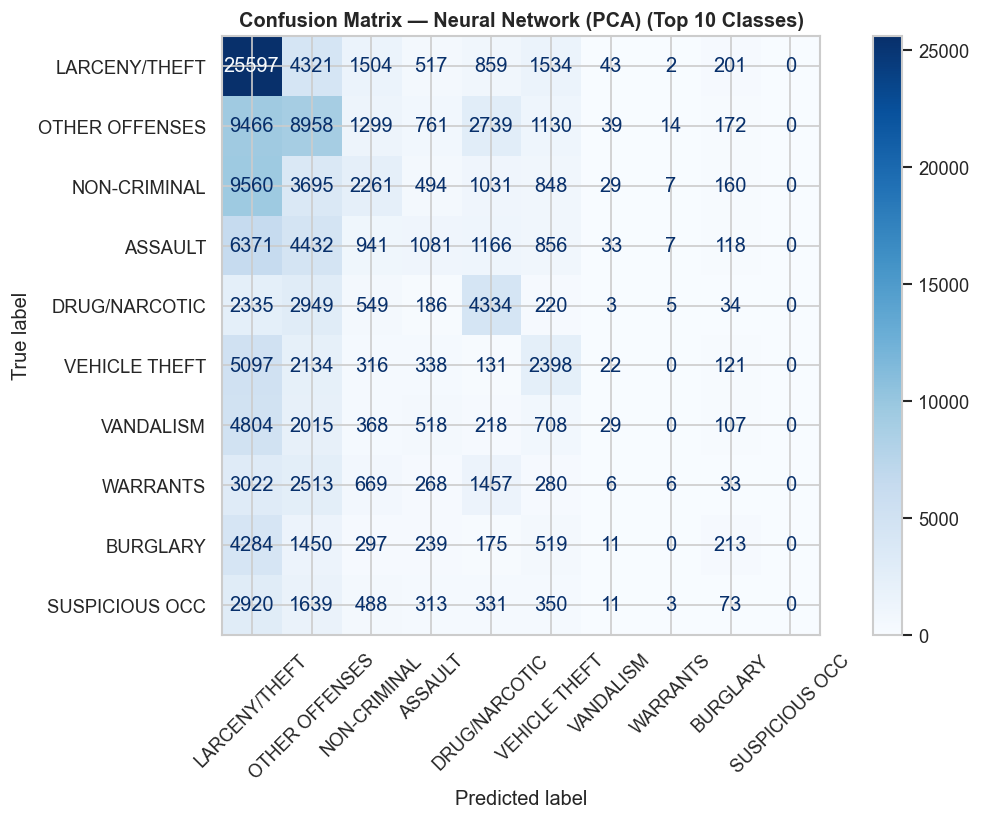

In [26]:
# ── Neural Network — PCA Data ──
print(' Training Neural Network on PCA data...')
nn_pca_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=100,
    batch_size=512,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)
nn_pca_model.fit(X_train_pca, y_train)
print(' Done!')

res = evaluate_model(nn_pca_model, X_train_pca, y_train,
                     X_test_pca, y_test,
                     model_name='Neural Network (PCA)')
results.append(res)


---
##  Section 8 — Model Comparison Table

A full comparison of all 8 model variants (4 models × 2 datasets).


In [27]:
# ── Build Comparison Table ──
results_df = pd.DataFrame(results)

# Add PCA column
results_df['Data'] = results_df['model'].apply(
    lambda x: 'PCA' if '(PCA)' in x else 'Original'
)
results_df['Model'] = results_df['model'].str.replace(
    r' \(Original\)| \(PCA\)', '', regex=True
)

# Reorder columns
display_df = results_df[['Model', 'Data', 'train_acc', 'test_acc', 
                          'precision', 'recall', 'f1', 'overfit']].copy()
display_df.columns = ['Model', 'Dataset', 'Train Acc (%)', 'Test Acc (%)',
                      'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'Overfit (%)']

# Sort by Test Accuracy
display_df = display_df.sort_values('Test Acc (%)', ascending=False).reset_index(drop=True)

print('=== FULL MODEL COMPARISON TABLE ===')
display_df


=== FULL MODEL COMPARISON TABLE ===


,Model,Dataset,Train Acc (%),Test Acc (%),Precision (%),Recall (%),F1-Score (%),Overfit (%)
0,Neural Network,PCA,27.34,26.82,21.67,26.82,20.07,0.51
1,Neural Network,Original,27.09,26.78,21.18,26.78,20.02,0.31
2,Decision Tree,Original,26.20,25.74,19.86,25.74,19.19,0.45
3,Decision Tree,PCA,25.02,24.31,18.36,24.31,16.72,0.70
4,Logistic Regression,PCA,21.51,21.50,10.98,21.50,11.37,0.01
5,Logistic Regression,Original,21.51,21.50,10.98,21.50,11.37,0.01
6,SVM LinearSVC,PCA,21.31,21.30,9.43,21.30,10.44,0.01
7,SVM LinearSVC,Original,21.31,21.30,9.43,21.30,10.44,0.01


In [28]:
# ── Highlight best model and overfitting cases ──
best_idx    = display_df['Test Acc (%)'].idxmax()
overfit_idx = display_df[display_df['Overfit (%)'] > 10].index.tolist()

best_model    = display_df.loc[best_idx, 'Model']
best_data     = display_df.loc[best_idx, 'Dataset']
best_acc      = display_df.loc[best_idx, 'Test Acc (%)']

print(f' Best Model : {best_model} — {best_data} data')
print(f'   Test Accuracy: {best_acc:.2f}%')

if overfit_idx:
    print('\n  Overfitting detected in:')
    for i in overfit_idx:
        row = display_df.loc[i]
        print(f'   - {row["Model"]} ({row["Dataset"]}): overfit gap = {row["Overfit (%)"]:.2f}%')
else:
    print('\n No significant overfitting detected (gap < 10% for all models)')


 Best Model : Neural Network — PCA data
   Test Accuracy: 26.82%

 No significant overfitting detected (gap < 10% for all models)


---
##  Section 9 — Performance Visualizations


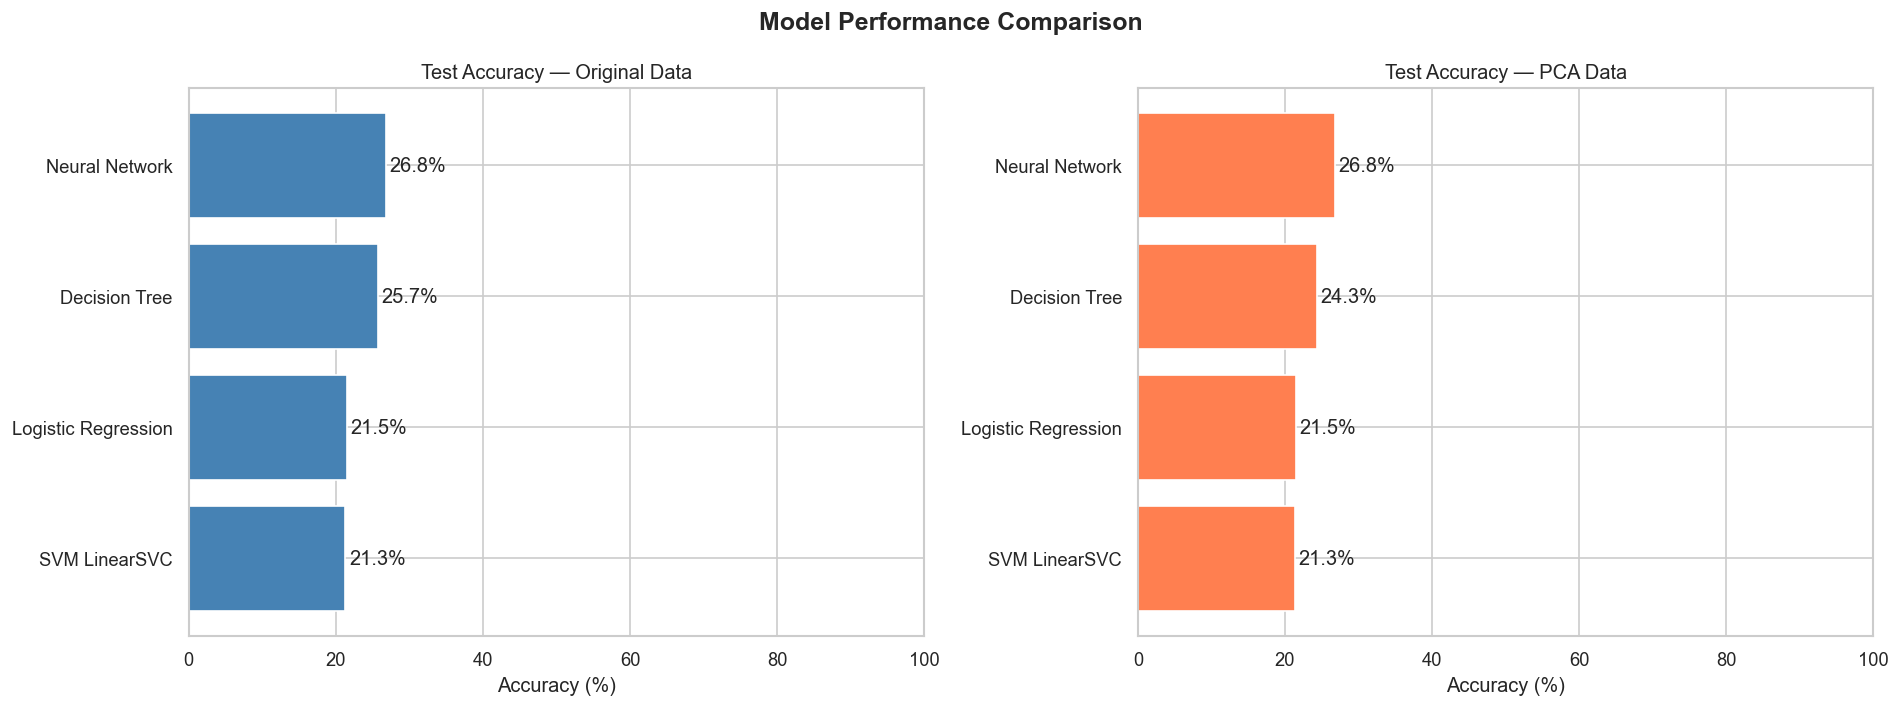

Accuracy comparison chart saved!


In [29]:
# ── Bar Chart: Test Accuracy Comparison ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

# Group by Original vs PCA
orig_df = display_df[display_df['Dataset'] == 'Original'].sort_values('Test Acc (%)')
pca_df  = display_df[display_df['Dataset'] == 'PCA'].sort_values('Test Acc (%)')

# Plot 1: Test Accuracy — Original data
bars1 = axes[0].barh(orig_df['Model'], orig_df['Test Acc (%)'], color='steelblue')
axes[0].set_title('Test Accuracy — Original Data')
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_xlim([0, 100])
for bar, val in zip(bars1, orig_df['Test Acc (%)']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center')

# Plot 2: Test Accuracy — PCA data
bars2 = axes[1].barh(pca_df['Model'], pca_df['Test Acc (%)'], color='coral')
axes[1].set_title('Test Accuracy — PCA Data')
axes[1].set_xlabel('Accuracy (%)')
axes[1].set_xlim([0, 100])
for bar, val in zip(bars2, pca_df['Test Acc (%)']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center')

plt.tight_layout()
plt.savefig('model_comparison_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Accuracy comparison chart saved!')


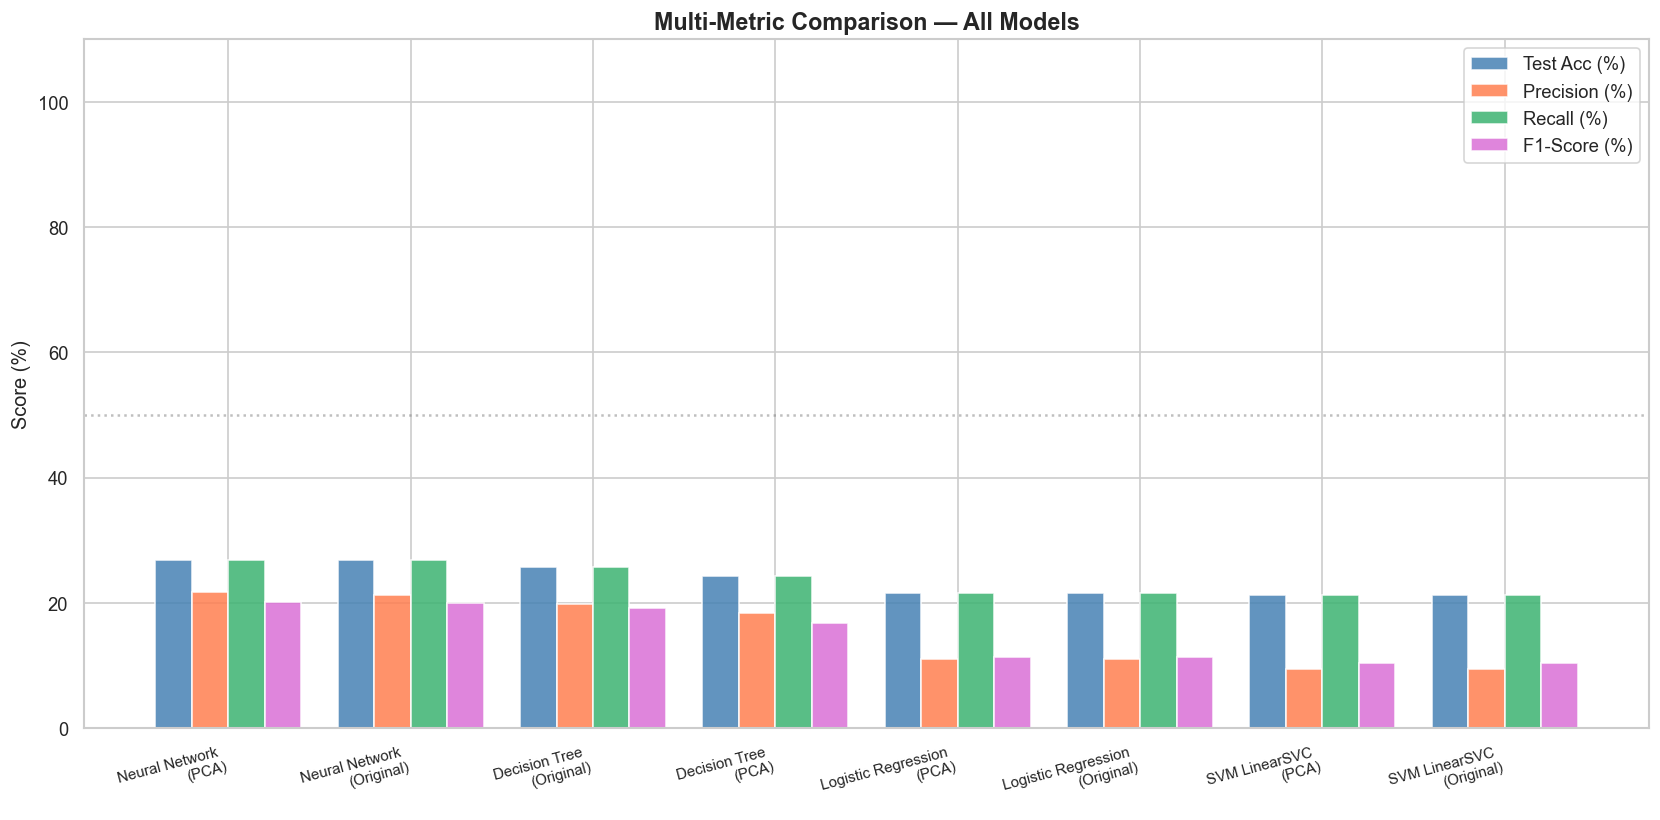

 Multi-metric comparison chart saved!


In [31]:
# ── Multi-Metric Comparison Chart ──
fig, ax = plt.subplots(figsize=(14, 7))

metrics = ['Test Acc (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
x = np.arange(len(display_df))
width = 0.2
colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, display_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(display_df['Model'] + ' \n(' + display_df['Dataset'] + ')',
                   rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_title('Multi-Metric Comparison — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim([0, 110])
ax.axhline(y=50, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Multi-metric comparison chart saved!')


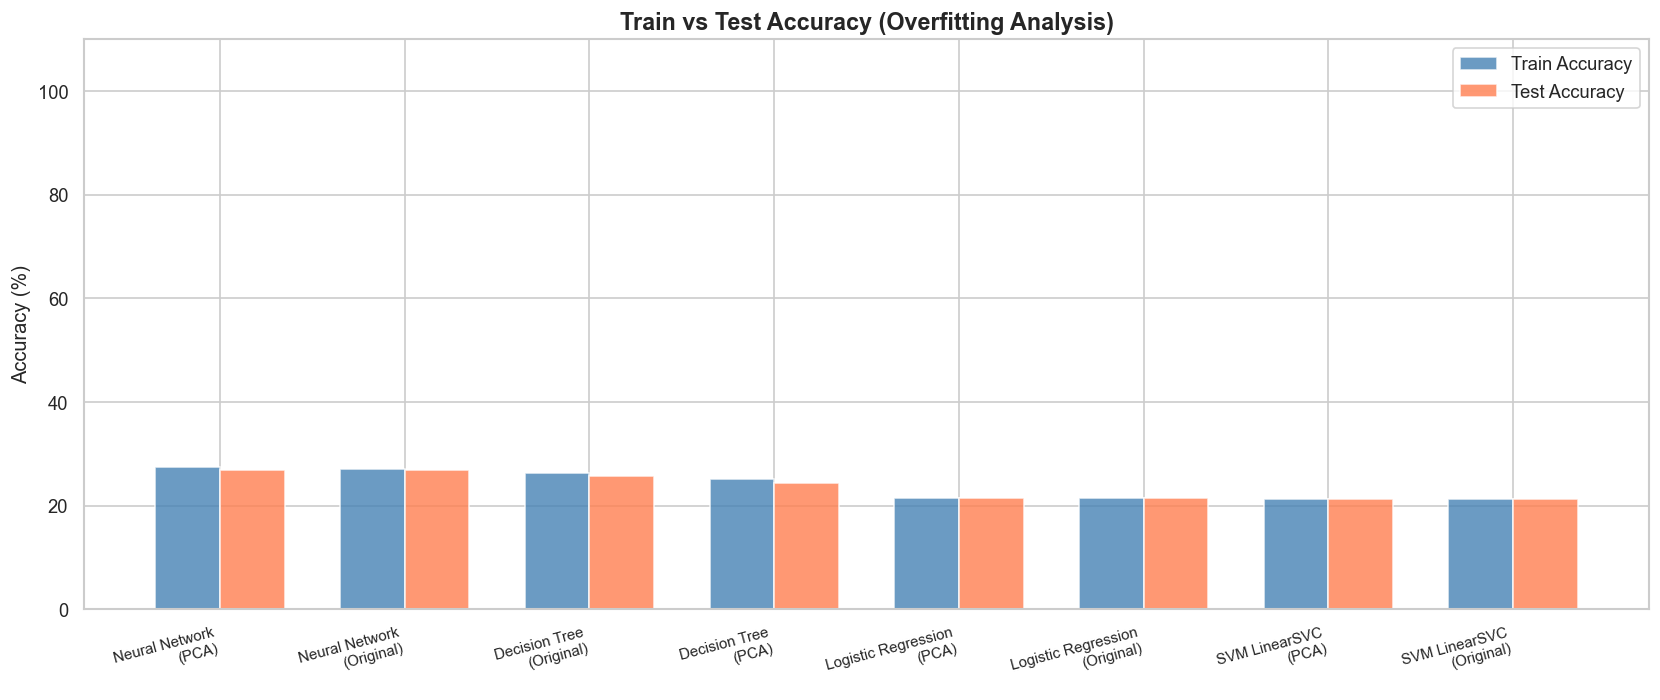

 Overfitting analysis chart saved!


In [32]:
# ── Train vs Test Accuracy (Overfitting Check) ──
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(display_df))
width = 0.35

bars_train = ax.bar(x - width/2, display_df['Train Acc (%)'], width,
                    label='Train Accuracy', color='steelblue', alpha=0.8)
bars_test  = ax.bar(x + width/2, display_df['Test Acc (%)'],  width,
                    label='Test Accuracy',  color='coral',     alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(display_df['Model'] + '\n(' + display_df['Dataset'] + ')',
                   rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Train vs Test Accuracy (Overfitting Analysis)', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim([0, 110])

# Draw overfit gap annotations
for i in range(len(display_df)):
    gap = display_df.iloc[i]['Overfit (%)']
    if gap > 5:
        ax.annotate(f'Δ{gap:.0f}%',
                    xy=(i, display_df.iloc[i]['Test Acc (%)'] + 1),
                    ha='center', color='red', fontsize=8)

plt.tight_layout()
plt.savefig('train_vs_test_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Overfitting analysis chart saved!')


---
##  Section 10 — Hyperparameter Tuning

We test multiple hyperparameter values for each model to find the best configuration.

> **Note**: We use the **original scaled** data and a smaller subset for speed.


In [33]:
# ── Use a subset for faster tuning ── tuning for check another way of train
TUNE_SIZE = 10000  # rows to use for tuning (fast experiments)

# Sample indices
tune_idx = np.random.choice(len(X_train_scaled), TUNE_SIZE, replace=False## for no replated the same row)
X_tune   = X_train_scaled[tune_idx]
y_tune   = y_train[tune_idx]

print(f' Tuning subset: {TUNE_SIZE:,} rows')
print('   (Using subset to keep experiments fast)')


 Tuning subset: 10,000 rows
   (Using subset to keep experiments fast)


In [34]:
# ── Decision Tree: Vary max_depth ──
print('\n=== Decision Tree — max_depth Tuning ===')
print(f'{"max_depth":<12} {"Train Acc":<12} {"Test Acc":<12}')
print('-' * 36)

dt_tune_results = []
for depth in [3, 5, 8, 10, 15, 20, None]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_tune, y_tune)
    tr = accuracy_score(y_tune, m.predict(X_tune)) * 100
    te = accuracy_score(y_test,  m.predict(X_test_scaled)) * 100
    label = str(depth) if depth else 'None (full)'
    print(f'{label:<12} {tr:<12.2f} {te:<12.2f}')
    dt_tune_results.append({'max_depth': label, 'train': tr, 'test': te})



=== Decision Tree — max_depth Tuning ===
max_depth    Train Acc    Test Acc    
------------------------------------
3            23.68        23.00       
5            24.55        23.11       
8            29.36        22.36       
10           36.62        21.18       
15           67.18        16.35       
20           93.24        14.25       
None (full)  99.67        14.00       


In [35]:
# ── Logistic Regression: Vary C ──
print('\n=== Logistic Regression — C Tuning ===')
print(f'{"C value":<12} {"Train Acc":<12} {"Test Acc":<12}')
print('-' * 36)

lr_tune_results = []
for c in [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]:
    m = LogisticRegression(C=c, max_iter=300, random_state=42, n_jobs=-1)
    m.fit(X_tune, y_tune)
    tr = accuracy_score(y_tune, m.predict(X_tune)) * 100
    te = accuracy_score(y_test,  m.predict(X_test_scaled)) * 100
    print(f'{c:<12} {tr:<12.2f} {te:<12.2f}')
    lr_tune_results.append({'C': c, 'train': tr, 'test': te})



=== Logistic Regression — C Tuning ===
C value      Train Acc    Test Acc    
------------------------------------
0.01         21.68        21.37       
0.1          21.72        21.39       
0.5          21.71        21.39       
1.0          21.73        21.39       
5.0          21.74        21.39       
10.0         21.73        21.38       


In [36]:
# ── SVM: Vary C ──
print('\n=== LinearSVC — C Tuning ===')
print(f'{"C value":<12} {"Train Acc":<12} {"Test Acc":<12}')
print('-' * 36)

svm_tune_results = []
for c in [0.001, 0.01, 0.1, 1.0, 5.0]:
    m = LinearSVC(C=c, max_iter=1000, random_state=42)
    m.fit(X_tune, y_tune)
    tr = accuracy_score(y_tune, m.predict(X_tune)) * 100
    te = accuracy_score(y_test,  m.predict(X_test_scaled)) * 100
    print(f'{c:<12} {tr:<12.2f} {te:<12.2f}')
    svm_tune_results.append({'C': c, 'train': tr, 'test': te})



=== LinearSVC — C Tuning ===
C value      Train Acc    Test Acc    
------------------------------------
0.001        21.68        21.27       
0.01         21.68        21.29       
0.1          21.70        21.29       
1.0          21.70        21.29       
5.0          21.70        21.29       


In [37]:
# ── Neural Network: Vary architecture ── 
print('\n=== Neural Network — Architecture Tuning ===')
print(f'{"Architecture":<22} {"Train Acc":<12} {"Test Acc":<12}')
print('-' * 46)

nn_tune_results = []
architectures = {
    '(64,)':         (64,),
    '(128, 64)':     (128, 64),
    '(256, 128, 64)':(256, 128, 64),
    '(512, 256, 128)':(512, 256, 128),
}

for name, arch in architectures.items():
    m = MLPClassifier(hidden_layer_sizes=arch, activation='relu', solver='adam',
                      alpha=0.001, max_iter=50, batch_size=256, random_state=42,
                      early_stopping=True, validation_fraction=0.1)
    m.fit(X_tune, y_tune)
    tr = accuracy_score(y_tune, m.predict(X_tune)) * 100
    te = accuracy_score(y_test,  m.predict(X_test_scaled)) * 100
    print(f'{name:<22} {tr:<12.2f} {te:<12.2f}')
    nn_tune_results.append({'architecture': name, 'train': tr, 'test': te})



=== Neural Network — Architecture Tuning ===
Architecture           Train Acc    Test Acc    
----------------------------------------------
(64,)                  23.62        22.45       
(128, 64)              23.89        22.26       
(256, 128, 64)         24.89        22.21       
(512, 256, 128)        23.35        21.42       


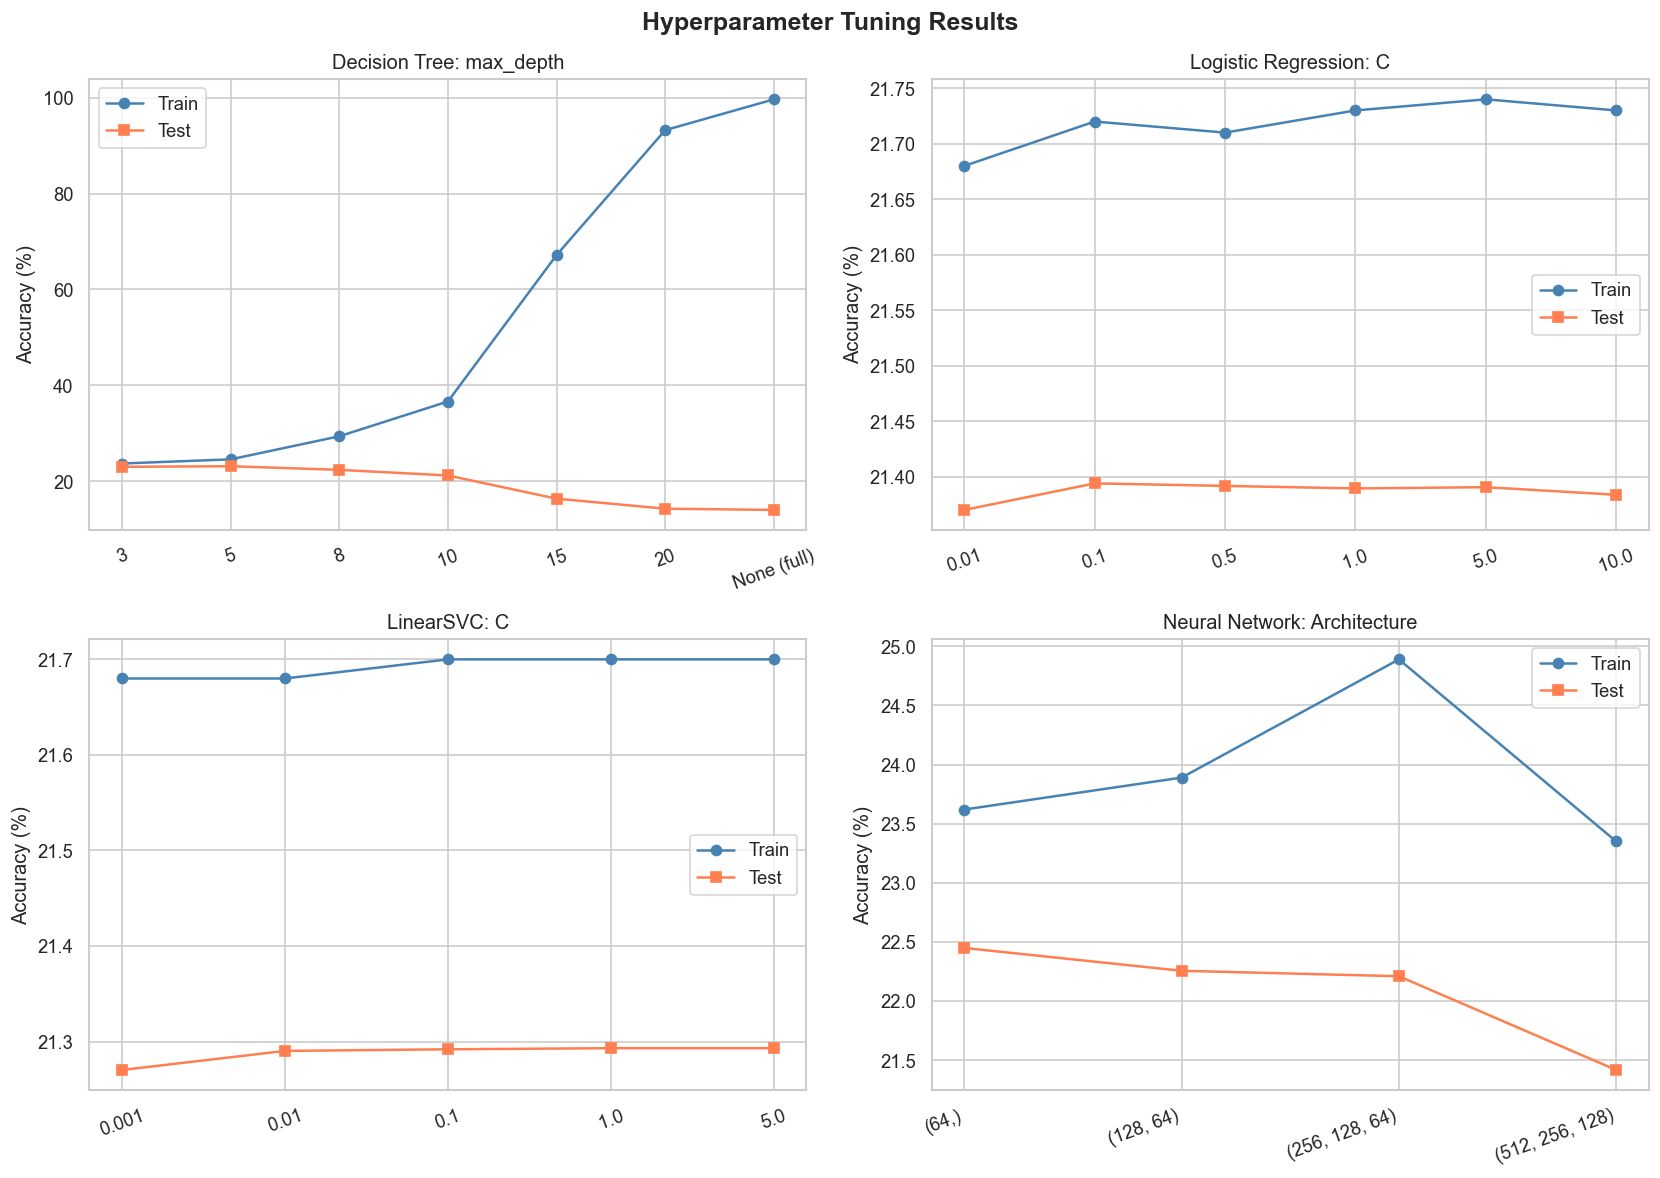

 Hyperparameter tuning plots saved!


In [38]:
# ── Hyperparameter Tuning Visualization ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hyperparameter Tuning Results', fontsize=15, fontweight='bold')

# Decision Tree
dt_df = pd.DataFrame(dt_tune_results)
axes[0, 0].plot(range(len(dt_df)), dt_df['train'], 'o-', label='Train', color='steelblue')
axes[0, 0].plot(range(len(dt_df)), dt_df['test'],  's-', label='Test',  color='coral')
axes[0, 0].set_xticks(range(len(dt_df)))
axes[0, 0].set_xticklabels(dt_df['max_depth'], rotation=20)
axes[0, 0].set_title('Decision Tree: max_depth')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].legend()

# Logistic Regression
lr_df = pd.DataFrame(lr_tune_results)
axes[0, 1].plot(range(len(lr_df)), lr_df['train'], 'o-', label='Train', color='steelblue')
axes[0, 1].plot(range(len(lr_df)), lr_df['test'],  's-', label='Test',  color='coral')
axes[0, 1].set_xticks(range(len(lr_df)))
axes[0, 1].set_xticklabels([str(x) for x in lr_df['C']], rotation=20)
axes[0, 1].set_title('Logistic Regression: C')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()

# SVM
svm_df = pd.DataFrame(svm_tune_results)
axes[1, 0].plot(range(len(svm_df)), svm_df['train'], 'o-', label='Train', color='steelblue')
axes[1, 0].plot(range(len(svm_df)), svm_df['test'],  's-', label='Test',  color='coral')
axes[1, 0].set_xticks(range(len(svm_df)))
axes[1, 0].set_xticklabels([str(x) for x in svm_df['C']], rotation=20)
axes[1, 0].set_title('LinearSVC: C')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()

# Neural Network
nn_df = pd.DataFrame(nn_tune_results)
axes[1, 1].plot(range(len(nn_df)), nn_df['train'], 'o-', label='Train', color='steelblue')
axes[1, 1].plot(range(len(nn_df)), nn_df['test'],  's-', label='Test',  color='coral')
axes[1, 1].set_xticks(range(len(nn_df)))
axes[1, 1].set_xticklabels(nn_df['architecture'], rotation=20, ha='right')
axes[1, 1].set_title('Neural Network: Architecture')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()]

plt.tight_layout()
plt.savefig('hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Hyperparameter tuning plots saved!')


---
##  Section 11 — Neural Network Loss Curve

Visualizing how the Neural Network learned over training epochs.
during time the model should reduice the loss
after 20 epoch the loss curve staked , no change and validatoin no big change (small overfitting)


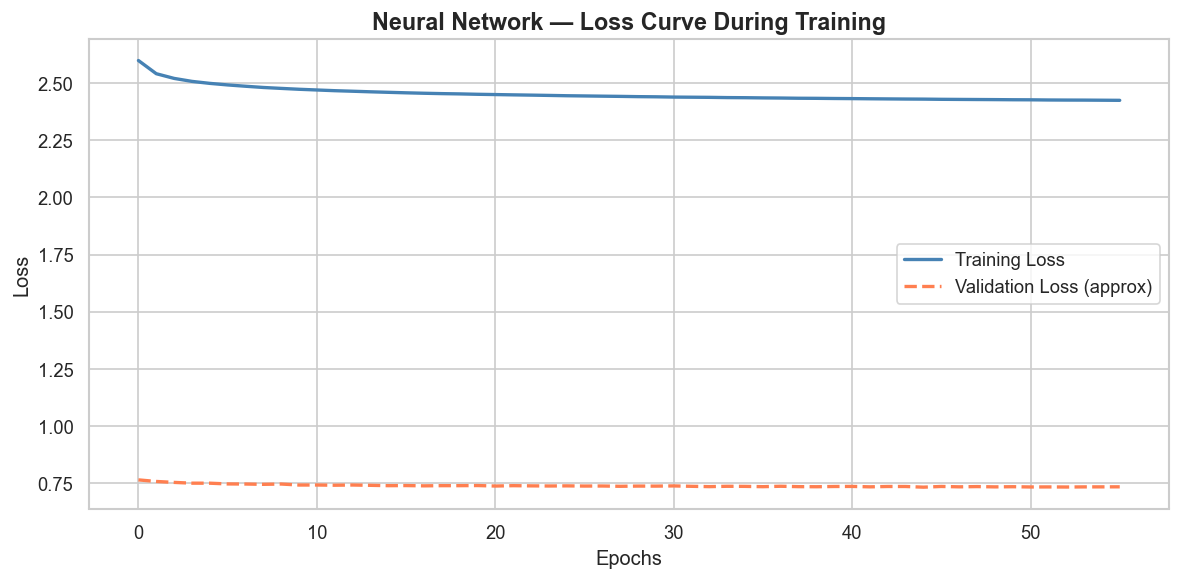

 Training completed in 56 iterations (with early stopping)


In [39]:
# ── Neural Network Loss Curve ──
plt.figure(figsize=(10, 5))
plt.plot(nn_model.loss_curve_, label='Training Loss', color='steelblue', linewidth=2)
if nn_model.validation_scores_ is not None:
    # validation_scores_ holds accuracy, invert to loss approximation
    val_loss = [1 - s for s in nn_model.validation_scores_]
    plt.plot(val_loss, label='Validation Loss (approx)', color='coral',
             linewidth=2, linestyle='--')
plt.title('Neural Network — Loss Curve During Training', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('nn_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Training completed in {nn_model.n_iter_} iterations (with early stopping)')


---
## Section 12 — Final Summary 


In [40]:
# ══════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════
print('\n' + '█' * 58)
print('    FINAL PROJECT SUMMARY')
print('█' * 58)

# Best model overall
best_row = display_df.loc[display_df['Test Acc (%)'].idxmax()]
print(f'\n    BEST MODEL')
print(f'      Name      : {best_row["Model"]}')
print(f'      Dataset   : {best_row["Dataset"]} data')
print(f'      Test Acc  : {best_row["Test Acc (%)"]:.2f}%')
print(f'      F1-Score  : {best_row["F1-Score (%)"]:.2f}%')
print(f'      Precision : {best_row["Precision (%)"]:.2f}%')
print(f'      Recall    : {best_row["Recall (%)"]:.2f}%')

# Overfit check
overfit_models = display_df[display_df['Overfit (%)'] > 10]
print(f'\n     OVERFITTING (gap > 10%)')
if len(overfit_models) == 0:
    print('      None detected — all models generalize well')
else:
    for _, r in overfit_models.iterrows():
        print(f'      {r["Model"]} ({r["Dataset"]}): {r["Overfit (%)"]:.1f}% gap')

# PCA impact
orig_avg = display_df[display_df['Dataset'] == 'Original']['Test Acc (%)'].mean()
pca_avg  = display_df[display_df['Dataset'] == 'PCA']['Test Acc (%)'].mean()
pca_delta = pca_avg - orig_avg
pca_impact = 'improved' if pca_delta > 0 else 'decreased'
print(f'\n    PCA IMPACT')
print(f'      Average accuracy {pca_impact} by {abs(pca_delta):.2f}% when using PCA')

print(f'\n   FULL RESULTS TABLE')
print('─' * 75)
print(display_df.to_string(index=False))
print('─' * 75)



██████████████████████████████████████████████████████████
    FINAL PROJECT SUMMARY
██████████████████████████████████████████████████████████

    BEST MODEL
      Name      : Neural Network
      Dataset   : PCA data
      Test Acc  : 26.82%
      F1-Score  : 20.07%
      Precision : 21.67%
      Recall    : 26.82%

     OVERFITTING (gap > 10%)
      None detected — all models generalize well

    PCA IMPACT
      Average accuracy decreased by 0.35% when using PCA

   FULL RESULTS TABLE
───────────────────────────────────────────────────────────────────────────
              Model  Dataset  Train Acc (%)  Test Acc (%)  Precision (%)  Recall (%)  F1-Score (%)  Overfit (%)
     Neural Network      PCA          27.34         26.82          21.67       26.82         20.07         0.51
     Neural Network Original          27.09         26.78          21.18       26.78         20.02         0.31
      Decision Tree Original          26.20         25.74          19.86       25.74        